In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

dataset_path = "/content/drive/MyDrive/AI_Precision_Agriculture/Phase-1_CNN/Dataset/PlantVillage"

print("Dataset path:")
print(dataset_path)

print("\nContents:")
print(os.listdir(dataset_path))

Dataset path:
/content/drive/MyDrive/AI_Precision_Agriculture/Phase-1_CNN/Dataset/PlantVillage

Contents:
['train', 'val']


In [4]:
train_path = os.path.join(dataset_path, "train")

print("Classes inside train:\n")

for item in sorted(os.listdir(train_path)):
    print(item)

Classes inside train:

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [5]:
all_classes = sorted(os.listdir(train_path))

corn_classes = [
    cls for cls in all_classes
    if cls.lower().startswith("corn")
]

tomato_classes = [
    cls for cls in all_classes
    if cls.lower().startswith("tomato")
]

print("CORN CLASSES:")
for cls in corn_classes:
    print("-", cls)

print("\nTOMATO CLASSES:")
for cls in tomato_classes:
    print("-", cls)

print("\nTotal Corn classes:", len(corn_classes))
print("Total Tomato classes:", len(tomato_classes))

CORN CLASSES:
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)___Common_rust_
- Corn_(maize)___Northern_Leaf_Blight
- Corn_(maize)___healthy

TOMATO CLASSES:
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Spot
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Tomato_mosaic_virus
- Tomato___healthy

Total Corn classes: 4
Total Tomato classes: 10


In [6]:
from collections import Counter
import os

def count_images(folder_path):
    counts = {}

    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            counts[class_name] = len(images)

    return counts


train_counts = count_images(train_path)

print("TRAIN DATASET")
print("=" * 50)

for class_name, count in train_counts.items():
    if class_name.lower().startswith(("corn", "tomato")):
        print(f"{class_name}: {count} images")

TRAIN DATASET
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410 images
Corn_(maize)___Common_rust_: 0 images
Corn_(maize)___Northern_Leaf_Blight: 0 images
Corn_(maize)___healthy: 929 images
Tomato___Bacterial_spot: 1702 images
Tomato___Early_blight: 800 images
Tomato___Late_blight: 1527 images
Tomato___Leaf_Mold: 0 images
Tomato___Septoria_leaf_spot: 1417 images
Tomato___Spider_mites Two-spotted_spider_mite: 0 images
Tomato___Target_Spot: 0 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1750 images
Tomato___Tomato_mosaic_virus: 0 images
Tomato___healthy: 1273 images


In [7]:
val_path = os.path.join(dataset_path, "val")

print("Validation classes:\n")

for item in sorted(os.listdir(val_path)):
    if item.lower().startswith(("corn", "tomato")):
        print(item)

Validation classes:

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy


In [25]:
print("TRAIN DATASET CHECK")
print("=" * 60)

for class_name in sorted(os.listdir(train_path)):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path) and class_name.lower().startswith(("corn", "tomato")):
        files = os.listdir(class_path)

        print(f"{class_name}: {len(files)} files")


TRAIN DATASET CHECK
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410 files
Corn_(maize)___Common_rust_: 953 files
Corn_(maize)___Northern_Leaf_Blight: 788 files
Corn_(maize)___healthy: 929 files
Tomato___Bacterial_spot: 1702 files
Tomato___Early_blight: 800 files
Tomato___Late_blight: 1527 files
Tomato___Leaf_Mold: 761 files
Tomato___Septoria_leaf_spot: 1417 files
Tomato___Spider_mites Two-spotted_spider_mite: 1341 files
Tomato___Target_Spot: 1123 files
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 4286 files
Tomato___Tomato_mosaic_virus: 299 files
Tomato___healthy: 1273 files


In [11]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
train_path = "/content/drive/MyDrive/AI_Precision_Agriculture/Phase-1_CNN/Dataset/PlantVillage/train"
image_extensions = (".jpg", ".jpeg", ".png")
image_paths = []
class_names = []
for class_name in sorted(os.listdir(train_path)):
    if not class_name.lower().startswith(("corn", "tomato")):
        continue

    class_path = os.path.join(train_path, class_name)

    if not os.path.isdir(class_path):
        continue
    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(image_extensions):

            image_paths.append(
                os.path.join(class_path, file_name)
            )

            class_names.append(class_name)


df = pd.DataFrame({
    "filepath": image_paths,
    "class": class_names
})

print("Total Corn + Tomato images:", len(df))
print("Total classes:", df["class"].nunique())

print("\nClasses:")
for cls in sorted(df["class"].unique()):
    print("-", cls)

print("\nImages per class:")
print(df["class"].value_counts().sort_index())

Total Corn + Tomato images: 17245
Total classes: 14

Classes:
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)___Common_rust_
- Corn_(maize)___Northern_Leaf_Blight
- Corn_(maize)___healthy
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Spot
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Tomato_mosaic_virus
- Tomato___healthy

Images per class:
class
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     410
Corn_(maize)___Common_rust_                            953
Corn_(maize)___Northern_Leaf_Blight                    788
Corn_(maize)___healthy                                 929
Tomato___Bacterial_spot                               1702
Tomato___Early_blight                                  800
Tomato___Late_blight                                  1527
Tomato___Leaf_Mold                                     761
Tomato___

In [12]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print("DATASET SPLIT")
print("=" * 50)

print("Total images      :", len(df))
print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

print("\nPercentages:")
print("Training   :", round(len(train_df) / len(df) * 100, 2), "%")
print("Validation :", round(len(val_df) / len(df) * 100, 2), "%")
print("Testing    :", round(len(test_df) / len(df) * 100, 2), "%")

DATASET SPLIT
Total images      : 17245
Training images   : 12071
Validation images : 2587
Testing images    : 2587

Percentages:
Training   : 70.0 %
Validation : 15.0 %
Testing    : 15.0 %


In [13]:
print("TRAINING")
print("=" * 50)
print(train_df["class"].value_counts().sort_index())

print("\nVALIDATION")
print("=" * 50)
print(val_df["class"].value_counts().sort_index())

print("\nTEST")
print("=" * 50)
print(test_df["class"].value_counts().sort_index())

TRAINING
class
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     287
Corn_(maize)___Common_rust_                            667
Corn_(maize)___Northern_Leaf_Blight                    552
Corn_(maize)___healthy                                 650
Tomato___Bacterial_spot                               1191
Tomato___Early_blight                                  560
Tomato___Late_blight                                  1069
Tomato___Leaf_Mold                                     533
Tomato___Septoria_leaf_spot                            992
Tomato___Spider_mites Two-spotted_spider_mite          684
Tomato___Target_Spot                                   786
Tomato___Tomato_Yellow_Leaf_Curl_Virus                3000
Tomato___Tomato_mosaic_virus                           209
Tomato___healthy                                       891
Name: count, dtype: int64

VALIDATION
class
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     61
Corn_(maize)___Common_rust_                           143

In [14]:
classes = sorted(df["class"].unique())

class_to_index = {
    class_name: index
    for index, class_name in enumerate(classes)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

print("Number of classes:", len(classes))
print("\nClass labels:")

for index, class_name in index_to_class.items():
    print(index, "=", class_name)

Number of classes: 14

Class labels:
0 = Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
1 = Corn_(maize)___Common_rust_
2 = Corn_(maize)___Northern_Leaf_Blight
3 = Corn_(maize)___healthy
4 = Tomato___Bacterial_spot
5 = Tomato___Early_blight
6 = Tomato___Late_blight
7 = Tomato___Leaf_Mold
8 = Tomato___Septoria_leaf_spot
9 = Tomato___Spider_mites Two-spotted_spider_mite
10 = Tomato___Target_Spot
11 = Tomato___Tomato_Yellow_Leaf_Curl_Virus
12 = Tomato___Tomato_mosaic_virus
13 = Tomato___healthy


In [26]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = len(classes)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Image size: (224, 224)
Batch size: 32
Number of classes: 14


In [27]:
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label
train_labels = train_df["class"].map(class_to_index).values
val_labels = val_df["class"].map(class_to_index).values
test_labels = test_df["class"].map(class_to_index).values
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_labels)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_df["filepath"].values, val_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_labels)
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)


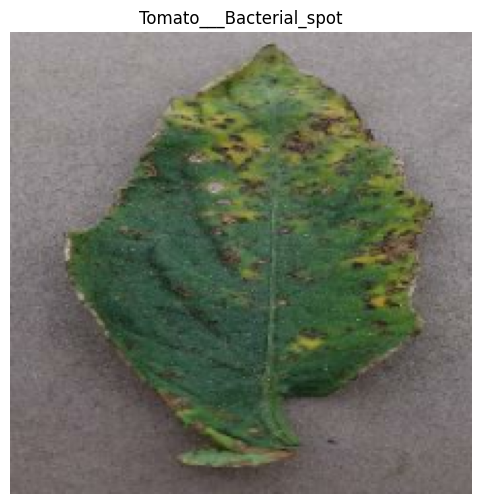

In [24]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

plt.figure(figsize=(6, 6))

plt.imshow(images[0])
plt.title(index_to_class[int(labels[0])])
plt.axis("off")

plt.show()

In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="data_augmentation")

print("Data augmentation created successfully.")

Data augmentation created successfully.


In [33]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN compiled successfully.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,766 (42.61 MB)

 Trainable params: 11,170,766 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

CNN compiled successfully.


In [43]:
from sklearn.model_selection import train_test_split

small_train_df, _ = train_test_split(
    train_df,
    train_size=2000,
    stratify=train_df["class"],
    random_state=42
)

small_val_df, _ = train_test_split(
    val_df,
    train_size=500,
    stratify=val_df["class"],
    random_state=42
)

small_train_df = small_train_df.reset_index(drop=True)
small_val_df = small_val_df.reset_index(drop=True)

print("Training images:", len(small_train_df))
print("Validation images:", len(small_val_df))
print("Classes:", len(classes))

Training images: 2000
Validation images: 500
Classes: 14


In [47]:
small_train_labels = small_train_df["class"].map(class_to_index).values
small_val_labels = small_val_df["class"].map(class_to_index).values

small_train_dataset = tf.data.Dataset.from_tensor_slices(
    (small_train_df["filepath"].values, small_train_labels)
).map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

small_val_dataset = tf.data.Dataset.from_tensor_slices(
    (small_val_df["filepath"].values, small_val_labels)
).map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Small datasets created successfully.")

Small datasets created successfully.


In [49]:
fast_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fast CNN compiled successfully.")

Fast CNN compiled successfully.


In [66]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history = fast_model.fit(
    small_train_dataset,
    validation_data=small_val_dataset,
    epochs=15,
    callbacks=[early_stopping]
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.2605 - loss: 2.3701 - val_accuracy: 0.2640 - val_loss: 2.3053
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.2505 - loss: 2.3617 - val_accuracy: 0.2580 - val_loss: 2.3035
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.2550 - loss: 2.3657 - val_accuracy: 0.2600 - val_loss: 2.2986
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.2580 - loss: 2.3575 - val_accuracy: 0.2580 - val_loss: 2.2905
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.2595 - loss: 2.3527 - val_accuracy: 0.2580 - val_loss: 2.2897
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.2610 - loss: 2.3542 - val_accuracy: 0.2580 - val_loss: 2.2819
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.2600 - loss: 2.3537 - val_accuracy: 0.2580 - val_loss: 2.2811
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.2590 - loss: 2.3500 - val_accuracy: 0.2600

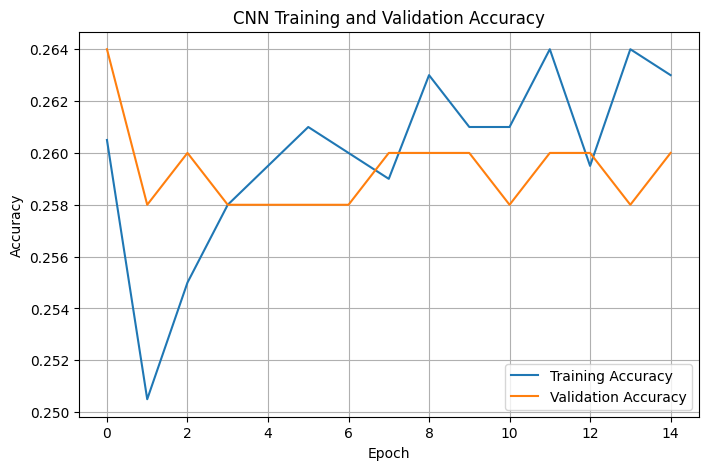

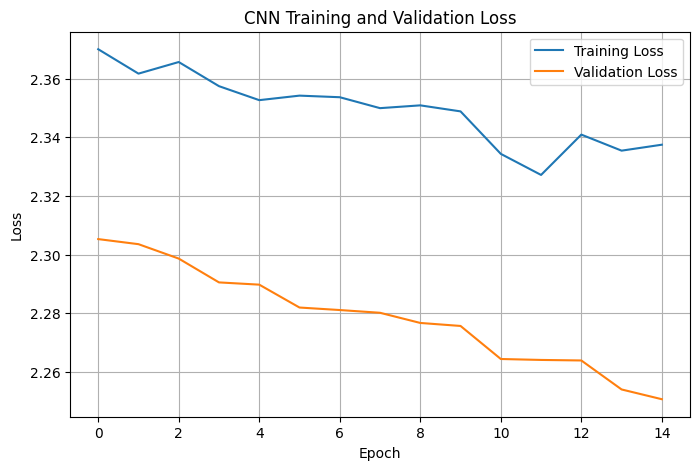

In [67]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [68]:
test_loss, test_accuracy = fast_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.2702 - loss: 2.2396
Test Loss: 2.239567279815674
Test Accuracy: 0.27019715309143066
Test Accuracy (%): 27.019715309143066


81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step


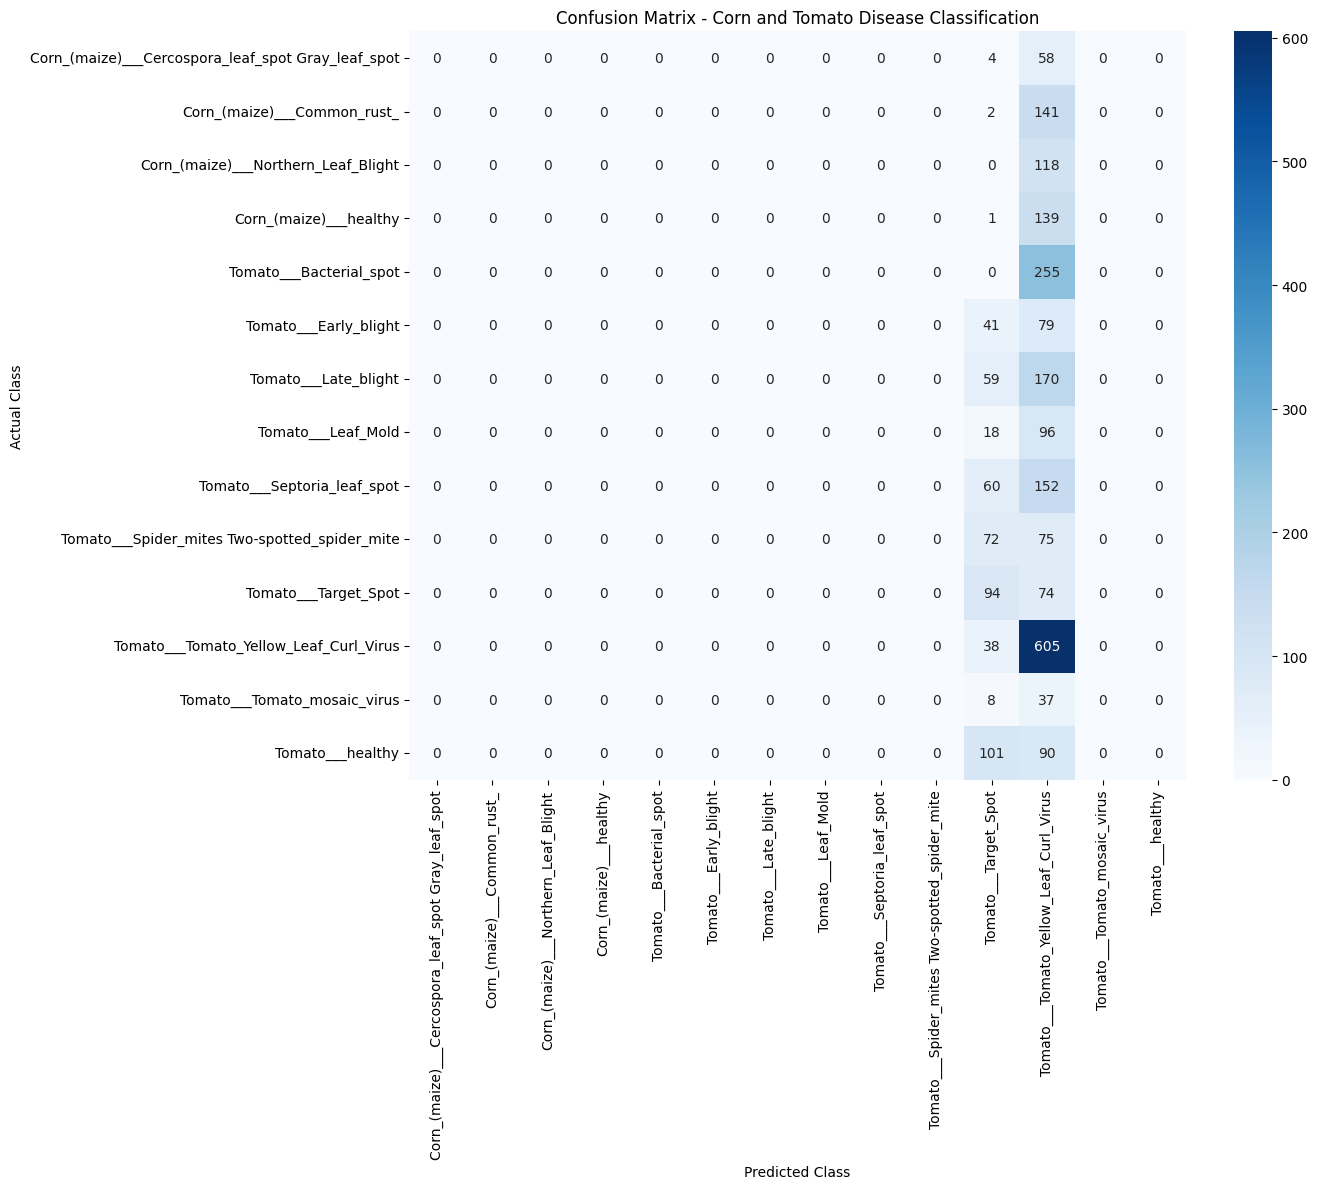

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
y_true = np.concatenate(
    [y.numpy() for x, y in test_dataset],
    axis=0
)
y_prob = fast_model.predict(test_dataset)
y_pred = np.argmax(y_prob, axis=1)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Corn and Tomato Disease Classification")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=classes
)

print(report)

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00        62
                       Corn_(maize)___Common_rust_       0.00      0.00      0.00       143
               Corn_(maize)___Northern_Leaf_Blight       0.00      0.00      0.00       118
                            Corn_(maize)___healthy       0.00      0.00      0.00       140
                           Tomato___Bacterial_spot       0.00      0.00      0.00       255
                             Tomato___Early_blight       0.00      0.00      0.00       120
                              Tomato___Late_blight       0.00      0.00      0.00       229
                                Tomato___Leaf_Mold       0.00      0.00      0.00       114
                       Tomato___Septoria_leaf_spot       0.00      0.00      0.00       212
     Tomato___Spider_mites Two-spotted_spider_mite       0.00      0.00      0.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))

print("Uploaded image:", filename)

Saving efe6c986-b85c-40f1-8cb5-345acbb36b71___RS_HL 0579.JPG to efe6c986-b85c-40f1-8cb5-345acbb36b71___RS_HL 0579.JPG
Uploaded image: efe6c986-b85c-40f1-8cb5-345acbb36b71___RS_HL 0579.JPG


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


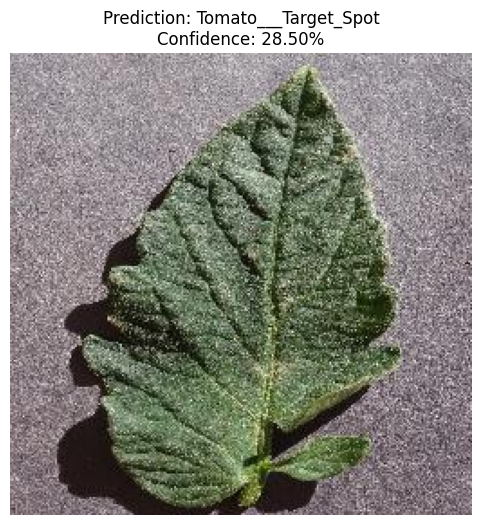

Predicted Class: Tomato___Target_Spot
Confidence: 28.50%


In [73]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
img = Image.open(filename).convert("RGB")
img_resized = img.resize((224, 224))
img_array = np.array(img_resized, dtype=np.float32) / 255.0
img_array = np.expand_dims(img_array, axis=0)
predictions = fast_model.predict(img_array)
predicted_index = np.argmax(predictions[0])
predicted_class = index_to_class[predicted_index]
confidence = predictions[0][predicted_index] * 100
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("Predicted Class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

In [74]:
top_3 = np.argsort(predictions[0])[-3:][::-1]

print("Top 3 Predictions:")
print()

for i in top_3:
    print(
        f"{index_to_class[i]}: "
        f"{predictions[0][i] * 100:.2f}%"
    )

Top 3 Predictions:

Tomato___Target_Spot: 28.50%
Tomato___healthy: 14.12%
Tomato___Spider_mites Two-spotted_spider_mite: 11.07%


In [75]:
model_path = "/content/drive/MyDrive/AI_Precision_Agriculture/Phase-1_CNN/plant_disease_mobilenetv2.keras"

fast_model.save(model_path)

print("Model saved successfully!")
print("Saved at:")
print(model_path)

Model saved successfully!
Saved at:
/content/drive/MyDrive/AI_Precision_Agriculture/Phase-1_CNN/plant_disease_mobilenetv2.keras


In [76]:
import os
if os.path.exists(model_path):
    file_size = os.path.getsize(model_path) / (1024 * 1024)
    print("Model file exists.")
    print(f"Model size: {file_size:.2f} MB")
else:
    print("Model file was not found.")


Model file exists.
Model size: 9.39 MB


In [77]:
print("=" * 60)
print("PHASE 1 - CNN CROP DISEASE DETECTION RESULTS")
print("=" * 60)

print("\nPROJECT:")
print("AI Driven Precision Agriculture System for Crop Health")
print("Monitoring and Yield Optimization")

print("\nDATASET:")
print("Total Corn + Tomato images: 17,245")
print("Number of classes:", len(classes))

print("\nDATA SPLIT:")
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

print("\nMODEL:")
print("MobileNetV2 Transfer Learning CNN")
print("Input image size: 224 x 224")
print("Number of output classes:", NUM_CLASSES)

print("\nTEST PERFORMANCE:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nCLASSES:")
for i, class_name in enumerate(classes):
    print(f"{i}: {class_name}")

print("\nMODEL FILE:")
print(model_path)

print("\n" + "=" * 60)
print("PHASE 1 COMPLETED")
print("=" * 60)

PHASE 1 - CNN CROP DISEASE DETECTION RESULTS

PROJECT:
AI Driven Precision Agriculture System for Crop Health
Monitoring and Yield Optimization

DATASET:
Total Corn + Tomato images: 17,245
Number of classes: 14

DATA SPLIT:
Training images: 12071
Validation images: 2587
Testing images: 2587

MODEL:
MobileNetV2 Transfer Learning CNN
Input image size: 224 x 224
Number of output classes: 14

TEST PERFORMANCE:
Test Loss: 2.2396
Test Accuracy: 0.2702
Test Accuracy: 27.02%

CLASSES:
0: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
1: Corn_(maize)___Common_rust_
2: Corn_(maize)___Northern_Leaf_Blight
3: Corn_(maize)___healthy
4: Tomato___Bacterial_spot
5: Tomato___Early_blight
6: Tomato___Late_blight
7: Tomato___Leaf_Mold
8: Tomato___Septoria_leaf_spot
9: Tomato___Spider_mites Two-spotted_spider_mite
10: Tomato___Target_Spot
11: Tomato___Tomato_Yellow_Leaf_Curl_Virus
12: Tomato___Tomato_mosaic_virus
13: Tomato___healthy

MODEL FILE:
/content/drive/MyDrive/AI_Precision_Agriculture/Phase-1